# Get start with the Colette Python API

## Install the ipywidgets package if not already installed

In [1]:
# !pip install -U ipywidgets

## Import necessary libraries

In [2]:
import json
import base64
from io import BytesIO
from PIL import Image
from IPython.display import display
import re

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

from colette.jsonapi import JSONApi
from colette.apidata import APIData

## Get paths and initialize variables

In [3]:
# Get the root path of the colette package
import os
colette_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
# print(f'Colette root path: {colette_root}')

In [4]:
documents_dir = os.path.join(colette_root, 'docs/pdf') # where the input documents are located
app_dir = os.path.join(colette_root, 'app_colette') # where to store the app
models_dir = os.path.join(colette_root, 'models') # where the models are located

config_file = os.path.join(colette_root, 'src/colette/config/vrag_default.json')
index_file = os.path.join(colette_root, 'src/colette/config/vrag_default_index.json')

app_name = 'app_colette' # name of the app

In [5]:
colette_api = JSONApi()

## Get config files and set parameters

In [6]:
# read the configuration file
with open(config_file, 'r') as f:
    create_config = json.load(f)
with open(index_file, 'r') as f:
    index_config = json.load(f)

create_config['app']['repository'] = app_dir
create_config['app']['models_repository'] = models_dir
index_config['parameters']['input']['data'] = [documents_dir]
#index_config['parameters']['input']['rag']['reindex'] = False # if True, the RAG will be reindexed


## Create the Service API client

In [7]:
api_data_create = APIData(**create_config)
colette_api.service_create(app_name, api_data_create)

2025-11-03 10:41:12,004 - api - INFO - creating service with name: app_colette (jsonapi.py:178)
/data1/ldejesus/repos/public/colette/venv_colette/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO 11-03 10:41:16 [__init__.py:216] Automatically detected platform cuda.


2025-11-03 10:41:19,272 - api - INFO - service using input lib: hf (jsonapi.py:239)
2025-11-03 10:41:19,273 - app_colette - INFO - Application directory: /data1/ldejesus/repos/public/colette/app_colette (llmservice.py:53)
2025-11-03 10:41:19,418 - app_colette - INFO - self.indexpath exists: True (rag_img.py:540)
2025-11-03 10:41:19,419 - app_colette - INFO - # collections: 0 (rag_img.py:543)
2025-11-03 10:41:19,419 - app_colette - INFO - has_existing_index: False (rag_img.py:574)
2025-11-03 10:41:19,420 - app_colette - INFO - HFModel initialized (hfmodel.py:81)
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 4/4 [00:07<00:00,  1.86s/it]


APIResponse(version=None, status_code=None, status=None, info=None, service_name='app_colette', full_prompt=None, full_response=None, sources=None, message=None, output=None)

## Index the documents

In [8]:
# index the documents
api_data_index = APIData(**index_config)
colette_api.service_index(app_name, api_data_index)

2025-11-03 10:41:38,440 - app_colette - INFO - get_data: read 1 files (inputconnector.py:70)
2025-11-03 10:41:38,440 - app_colette - INFO - Layout model already exists at /data1/ldejesus/repos/public/colette/models/layout_detector_publaynet_merged_6000.pt (layout_detector.py:55)
2025-11-03 10:41:38,991 - app_colette - INFO - Creating new index (rag_img.py:648)
The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.
Indexing documents:   0%|          | 0/1 [00:00<?, ?it/s]2025-11-03 10:41:48,768 - app_colette - INFO - Indexing document /data1/ldejesus/repos/public/colette/docs/pdf/COLETTEv2_Restitution_2025_03_07_v0.3_JB_light.pdf (rag_img.py:722)
2025-11-03 

APIResponse(version=None, status_code=None, status=None, info=None, service_name='app_colette', full_prompt=None, full_response=None, sources=None, message='None elements in rag_index', output=None)

## Query the documents

Note the optional 'crop_label' parameter to filter the sources by crop label.

The default crop labels are: 'text', 'table', 'figure'

In [9]:
# query the vision RAG
query_api_msg = {
    'parameters': {
        'input': {
            'message': 'What are the identified sources of errors ?',
            'crop_label': 'text'
        }
    }
}

query_data = APIData(**query_api_msg)
response = colette_api.service_predict(app_name, query_data)

2025-11-03 10:44:30,841 - api - INFO - predicting service with name: app_colette (jsonapi.py:265)
2025-11-03 10:44:30,877 - app_colette - INFO - Input transform and document retrieval took 0.04 seconds (hflib.py:72)
2025-11-03 10:44:46,282 - app_colette - INFO - LLM generation took 15.40 seconds (hflib.py:99)


In [10]:
print(response.output)

Based on the provided text from the document, the identified sources of errors are:

1.  **The lack of an automatic learning component:** The text on page 5 explicitly states, "Sans composante d'apprentissage automatique, celui-ci est fait « à la main »" (Without an automatic learning component, it is done "by hand"). This manual process is presented as the root cause.
2.  **Manual implementation and error correction:** Because the system is built and maintained manually, errors are observed, and "tentatives de correction « programmatiques »" (programmatic correction attempts) are implemented. This manual correction process is what leads to the accumulation of errors.
3.  **The resulting cascade of errors:** The text on page 5 describes a "cascade d'erreurs et de difficultés" (cascade of errors and difficulties), indicating that errors propagate and compound over time.

In essence, the primary source of errors is the manual, non-automated nature of the RAG system's development and main

In [11]:
# Function to extract and display image from base64 data URI
def display_image_from_data_uri(data_uri):
    # Extract base64 string (remove 'data:image/png;base64,' prefix)
    base64_str = re.sub('^data:image/.+;base64,', '', data_uri)
    
    # Decode base64 string
    image_data = base64.b64decode(base64_str)
    
    # Create PIL Image
    image = Image.open(BytesIO(image_data))
    
    # Display image
    display(image)
    
    return image

Key: f74f88ba-5488-5b1b-91a0-ea1f65f802d8_0013_crop_0000
Distance: 0.8982047438621521
crop_label: text


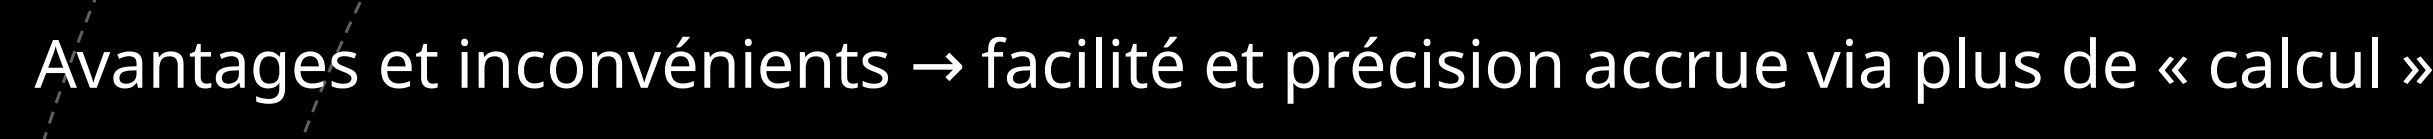

Image size: (2433, 139)
--------------------------------------------------
Key: f74f88ba-5488-5b1b-91a0-ea1f65f802d8_0006_crop_0002
Distance: 0.8393793106079102
crop_label: text


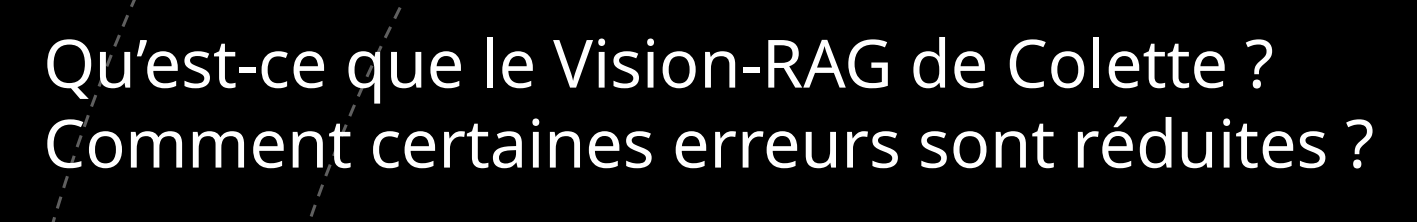

Image size: (1417, 222)
--------------------------------------------------
Key: f74f88ba-5488-5b1b-91a0-ea1f65f802d8_0004_crop_0002
Distance: 0.7907705307006836
crop_label: text


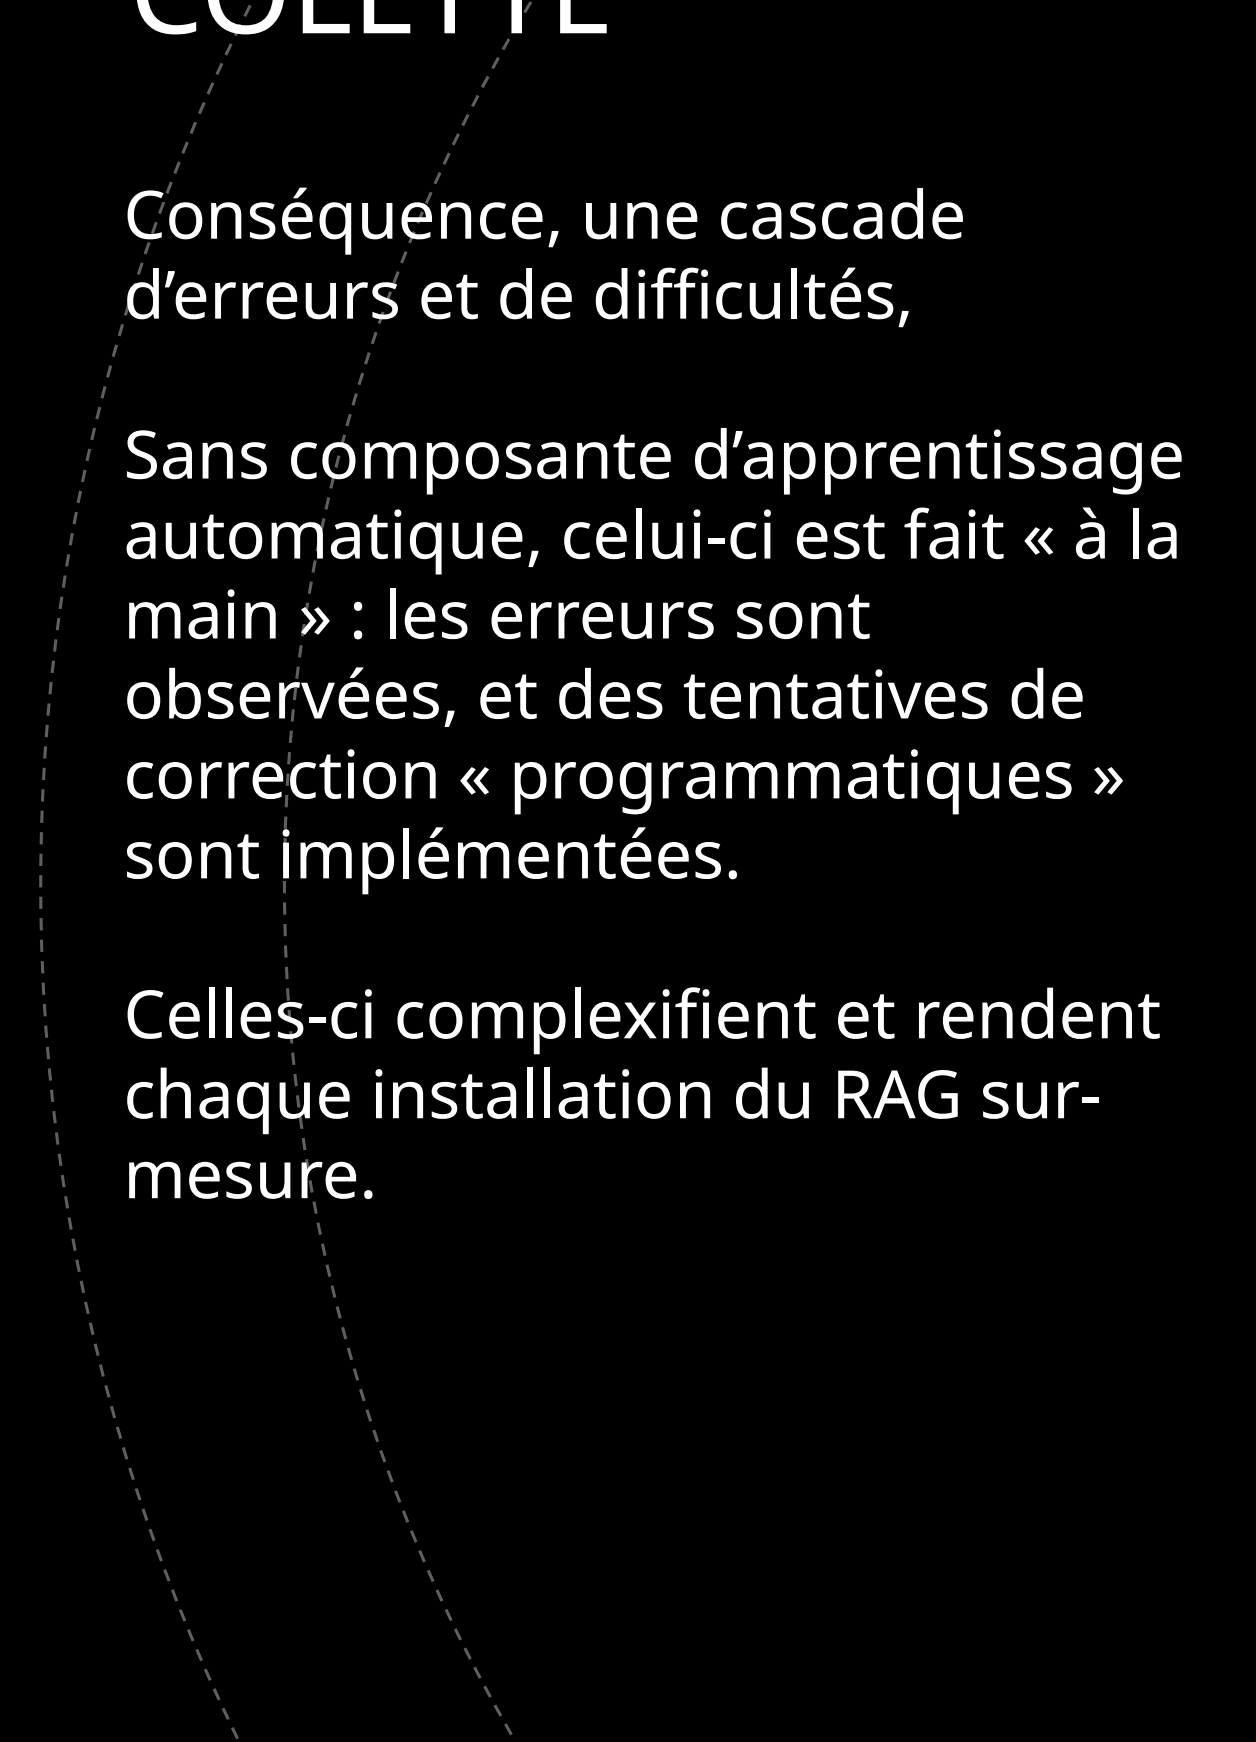

Image size: (1256, 1742)
--------------------------------------------------
Key: f74f88ba-5488-5b1b-91a0-ea1f65f802d8_0003_crop_0000
Distance: 0.7694706320762634
crop_label: text


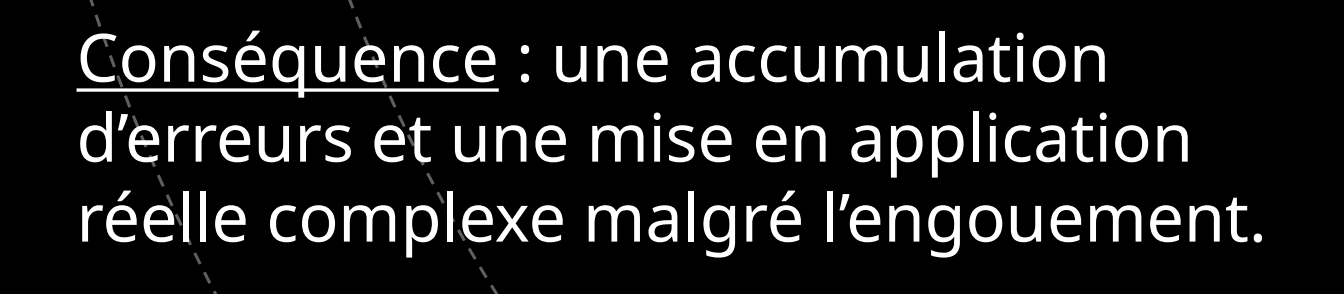

Image size: (1344, 294)
--------------------------------------------------


In [12]:
# Display all images in your context
for item in response.sources['context']:
    print(f"Key: {item['key']}")
    print(f"Distance: {item['distance']}")
    print(f'crop_label: {item.get("crop_label", "N/A")}')
    image = display_image_from_data_uri(item['content'])
    print(f"Image size: {image.size}")
    print("-" * 50)